1. Data Preprocessing

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [25]:
df = pd.read_csv("Quote-Equity-ASIANPAINT-EQ-19-04-2025-19-04-2026.csv")
print(df.head())

         DATE SERIES      OPEN    HIGH       LOW PREV. CLOSE       LTP  \
0  17-04-2026     EQ  2,425.00  2486.1  2,417.50    2,440.30  2,471.60   
1  16-04-2026     EQ  2,435.00  2446.6  2,411.60    2,423.10  2,438.00   
2  15-04-2026     EQ  2,400.50  2426.0  2,381.00    2,352.40  2,420.70   
3  13-04-2026     EQ  2,279.90  2362.5  2,262.00    2,360.70  2,348.00   
4  10-04-2026     EQ  2,267.70  2376.9  2,267.70    2,269.60  2,356.00   

      CLOSE      VWAP     52W H     52W L     VOLUME              VALUE  \
0  2,464.00  2,464.88  2,985.70  2,115.00  1286575.0  3,17,12,50,206.90   
1  2,440.30  2,434.82  2,985.70  2,115.00  1496210.0  3,64,30,08,751.90   
2  2,423.10  2,414.03  2,985.70  2,115.00  1182431.0  2,85,44,23,588.30   
3  2,352.40  2,331.49  2,985.70  2,115.00  1734562.0  4,04,41,20,223.30   
4  2,360.70  2,352.32  2,985.70  2,115.00  3018178.0  7,09,97,21,354.80   

   NO. OF  TRADES  
0          104371  
1          125188  
2          104794  
3          110738  
4   

In [26]:
df.columns = df.columns.str.replace(' ', '_').str.replace('.', '', regex=False)

In [27]:
df['DATE'] = pd.to_datetime(df['DATE'], dayfirst=True)

In [28]:
df = df.sort_values(by='DATE')
df.set_index('DATE', inplace=True)

In [29]:
numeric_cols = df.columns.drop(['SERIES'])

df[numeric_cols] = (
    df[numeric_cols]
    .astype(str)
    .apply(lambda x: x.str.replace(',', ''))
    .apply(pd.to_numeric, errors='coerce')
)

In [30]:
print(df.isnull().sum())

SERIES           0
OPEN             0
HIGH             0
LOW              0
PREV_CLOSE       0
LTP              0
CLOSE            0
VWAP             0
52W_H            0
52W_L            0
VOLUME           0
VALUE            0
NO_OF__TRADES    0
dtype: int64


In [31]:
print(df.head())

           SERIES    OPEN    HIGH     LOW  PREV_CLOSE     LTP   CLOSE  \
DATE                                                                    
2025-04-21     EQ  2465.9  2470.9  2441.0      2467.9  2444.8  2445.0   
2025-04-22     EQ  2445.0  2450.0  2413.5      2445.0  2428.0  2432.0   
2025-04-23     EQ  2437.0  2456.6  2425.6      2432.0  2447.5  2453.1   
2025-04-24     EQ  2450.0  2491.0  2435.9      2453.1  2466.4  2464.4   
2025-04-25     EQ  2464.3  2468.7  2413.7      2464.4  2425.7  2431.6   

               VWAP   52W_H    52W_L     VOLUME         VALUE  NO_OF__TRADES  
DATE                                                                          
2025-04-21  2455.74  3394.9  2124.75   541913.0  1.330798e+09          43480  
2025-04-22  2434.93  3394.9  2124.75   543658.0  1.323770e+09          52528  
2025-04-23  2443.84  3394.9  2124.75   744696.0  1.819921e+09          53899  
2025-04-24  2465.69  3394.9  2124.75  1203452.0  2.967336e+09          77050  
2025-04-25  24

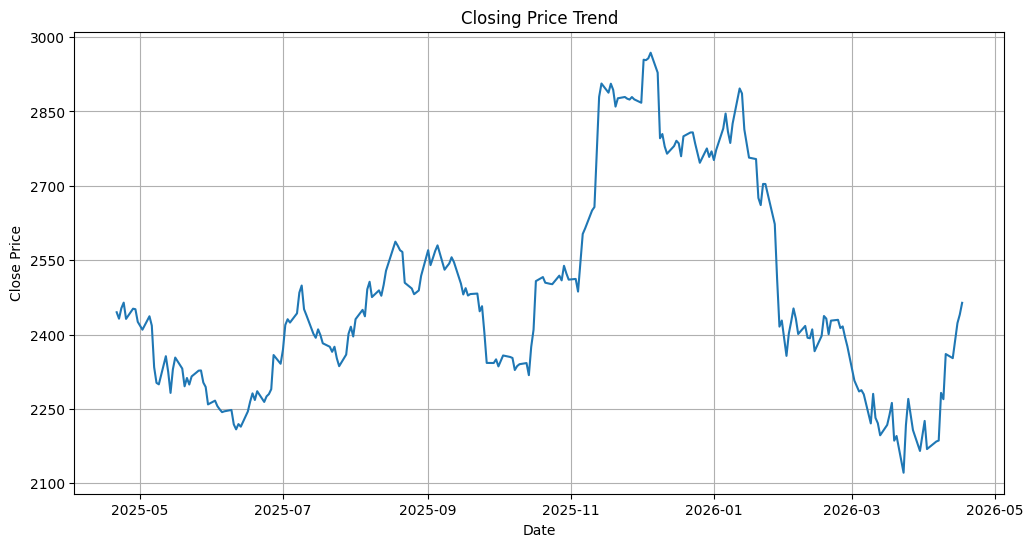

In [32]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['CLOSE'])

plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(8))

plt.title("Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid()
plt.show()

2. ARIMA Model Implementation

In [33]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [34]:
series = df['CLOSE']
series_diff = series.diff().dropna()

result = adfuller(series_diff)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -14.107659976948685
p-value: 2.5525673242505367e-26


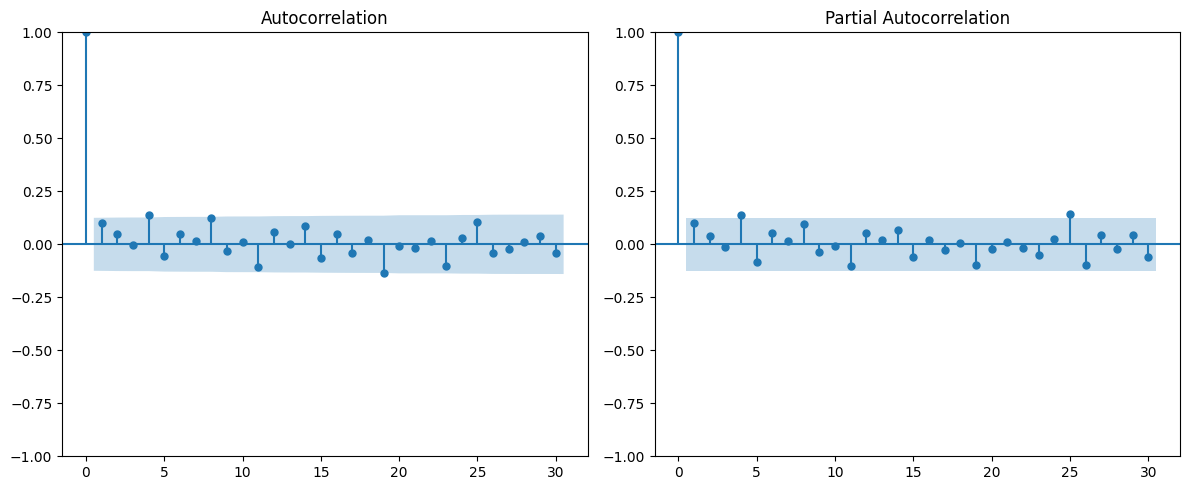

In [35]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(series_diff, ax=plt.gca(), lags=30)

plt.subplot(1,2,2)
plot_pacf(series_diff, ax=plt.gca(), lags=30)

plt.tight_layout()
plt.show()

The ACF plot shows a significant spike at lag 1 followed by a gradual decay, suggesting a moving average component.
The PACF plot shows a sharp cutoff after lag 1, indicating an autoregressive component.
Therefore, the ARIMA model parameters are selected as (p, d, q) = (1, 1, 1).

In [36]:
model = ARIMA(series, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  CLOSE   No. Observations:                  247
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1233.118
Date:                Sun, 19 Apr 2026   AIC                           2472.236
Time:                        17:46:38   BIC                           2482.752
Sample:                             0   HQIC                          2476.471
                                - 247                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7948      0.258      3.079      0.002       0.289       1.301
ma.L1         -0.7227      0.292     -2.479      0.013      -1.294      -0.151
sigma2      1321.7175     94.059     14.052      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [37]:
from statsmodels.tsa.arima.model import ARIMA

series = df['CLOSE']

models = [(1,1,0), (1,1,1), (2,1,1), (2,1,0)]

for order in models:
    model = ARIMA(series, order=order)
    model_fit = model.fit()
    print(f"ARIMA{order} → AIC: {model_fit.aic}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA(1, 1, 0) → AIC: 2471.2229314657734
ARIMA(1, 1, 1) → AIC: 2472.2364188309184
ARIMA(2, 1, 1) → AIC: 2466.228617619323
ARIMA(2, 1, 0) → AIC: 2472.8403923885244


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Based on the ACF and PACF plots, an initial ARIMA(1,1,1) model was considered.
However, multiple models were evaluated using the Akaike Information Criterion (AIC).
Among the tested models, ARIMA(2,1,1) produced the lowest AIC value, indicating a better fit.
Therefore, ARIMA(2,1,1) was selected as the optimal model.

In [38]:
model = ARIMA(series, order=(2,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  CLOSE   No. Observations:                  247
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -1229.114
Date:                Sun, 19 Apr 2026   AIC                           2466.229
Time:                        17:46:42   BIC                           2480.250
Sample:                             0   HQIC                          2471.874
                                - 247                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7926      0.087     -9.114      0.000      -0.963      -0.622
ar.L2          0.1766      0.058      3.063      0.002       0.064       0.290
ma.L1          0.9149      0.071     12.899      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


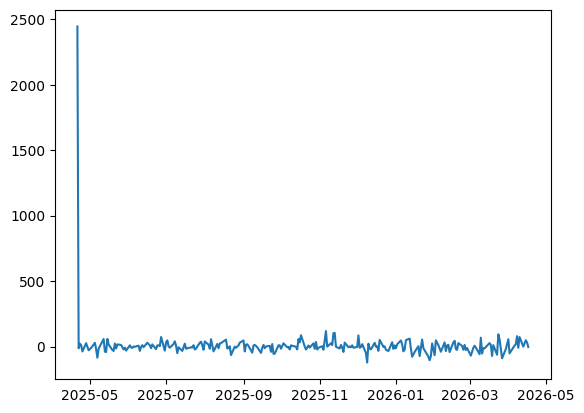

In [39]:
residuals = model_fit.resid
plt.plot(residuals)
plt.show()

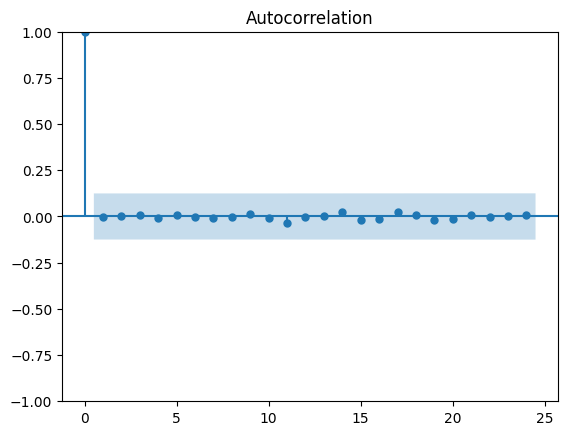

In [40]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals)
plt.show()

The residual ACF plot shows no significant spikes beyond lag 0, indicating that the residuals resemble white noise. This confirms that the model has captured the underlying patterns effectively.

In [41]:
model = ARIMA(series, order=(2,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=30)

print(forecast)

247    2445.406297
248    2464.329687
249    2446.046747
250    2463.880267
251    2446.516075
252    2463.428896
253    2446.956730
254    2462.999906
255    2447.374581
256    2462.592944
257    2447.770945
258    2462.206904
259    2448.146930
260    2461.840711
261    2448.503586
262    2461.493345
263    2448.841905
264    2461.163837
265    2449.162831
266    2460.851270
267    2449.467257
268    2460.554772
269    2449.756032
270    2460.273518
271    2450.029961
272    2460.006724
273    2450.289806
274    2459.753646
275    2450.536293
276    2459.513580
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

In [42]:
future_dates = pd.date_range(start=df.index[-1], periods=31, freq='D')[1:]

In [43]:
forecast_series = pd.Series(forecast.values, index=future_dates)

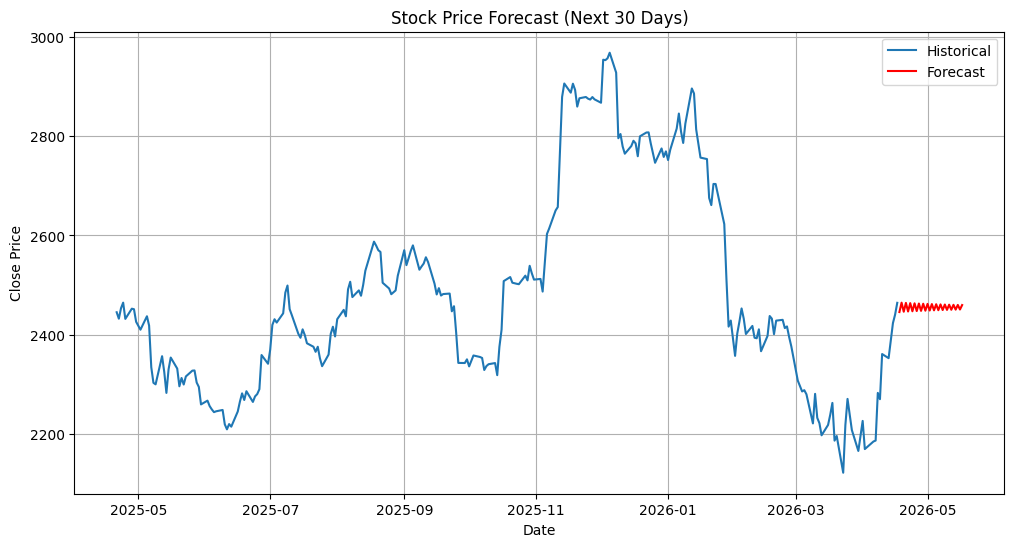

In [44]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['CLOSE'], label='Historical')

plt.plot(forecast_series.index, forecast_series, label='Forecast', color='red')

plt.title("Stock Price Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid()

plt.show()

The forecasted values suggest that the stock price will remain relatively stable over the next 30 days, exhibiting small fluctuations but no clear upward or downward trend. This indicates that the market is expected to maintain a steady behavior in the short term.
